In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [9]:
# ==========================================
# CREATE TRAIN, VALIDATION AND TEST DATASETS
# ==========================================

import tensorflow as tf

DATASET_PATH = "../dataset/color"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation + test data
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Get class names
class_names = train_dataset.class_names

print("Number of classes:", len(class_names))
print("Classes:", class_names)

# Split validation data into validation and test
total_batches = tf.data.experimental.cardinality(val_test_dataset).numpy()

test_batches = total_batches // 2

test_dataset = val_test_dataset.take(test_batches)
validation_dataset = val_test_dataset.skip(test_batches)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bact

In [10]:
# ==========================================
# OPTIMIZE DATASET PIPELINE
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(500).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipeline ready without cache!")

Dataset pipeline ready without cache!


In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 21s 2us/step
MobileNetV2 loaded successfully!


In [5]:
base_model.trainable = False

print("Base model frozen.")

Base model frozen.


In [6]:
model = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation="softmax")
])

print("Transfer Learning model created!")

Transfer Learning model created!


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [9]:
import os

os.makedirs("../models", exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [7]:
# ==========================================
# CREATE MOBILENETV2 TRANSFER LEARNING MODEL
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

# Make sure class_names exists
print("Number of classes:", len(class_names))

# Load pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pre-trained layers
base_model.trainable = False

# Create the model
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation="softmax")
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model created successfully!")

Number of classes: 38
MobileNetV2 model created successfully!


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import os

os.makedirs("../models", exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(=
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [11]:
print("Train dataset:", train_dataset)
print("Validation dataset:", validation_dataset)
print("Test dataset:", test_dataset)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [19]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "../models/best_mobilenetv2.keras"
)

print("Best MobileNetV2 model loaded successfully!")

Best MobileNetV2 model loaded successfully!


In [20]:
# ==========================================
# MOBILENETV2 FINE-TUNING - STEP 1
# ==========================================

base_model = model.layers[0]

# Allow training of MobileNetV2 layers
base_model.trainable = True

# Freeze all except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Fine-tuning setup completed!")
print("Total MobileNetV2 layers:", len(base_model.layers))

Fine-tuning setup completed!
Total MobileNetV2 layers: 154


In [21]:
# ==========================================
# MOBILENETV2 FINE-TUNING - STEP 2
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_ft = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=[early_stopping_ft, checkpoint_ft]
)

Epoch 1/5


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.7122 - loss: 0.9631
Epoch 1: val_accuracy improved from None to 0.80317, saving model to ../models/best_mobilenetv2_finetuned.keras

Epoch 1: finished saving model to ../models/best_mobilenetv2_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1045s 747ms/step - accuracy: 0.7122 - loss: 0.9631 - val_accuracy: 0.8032 - val_loss: 0.6639
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.7474 - loss: 0.8315
Epoch 2: val_accuracy improved from 0.80317 to 0.83398, saving model to ../models/best_mobilenetv2_finetuned.keras

Epoch 2: finished saving model to ../models/best_mobilenetv2_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 943s 676ms/step - accuracy: 0.7474 - loss: 0.8315 - val_accuracy: 0.8340 - val_loss: 0.5574
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.7708 - loss: 0.7488
Epoch 3: val_accuracy improved from 0.83398 to 0.83859, saving model to ../models/best_mobilenetv2_finetuned.kera

In [22]:
# ==========================================
# FINE-TUNED MODEL - TEST EVALUATION
# ==========================================

test_loss, test_accuracy = model.evaluate(test_dataset)

print("Fine-tuned Test Loss:", test_loss)
print("Fine-tuned Test Accuracy:", test_accuracy)

170/170 ━━━━━━━━━━━━━━━━━━━━ 88s 518ms/step - accuracy: 0.8625 - loss: 0.4494
Fine-tuned Test Loss: 0.44944050908088684
Fine-tuned Test Accuracy: 0.862500011920929


In [23]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.36      0.53        66
                                 Apple___Black_rot       0.88      0.90      0.89        68
                          Apple___Cedar_apple_rust       1.00      0.55      0.71        29
                                   Apple___healthy       0.81      0.84      0.82       163
                               Blueberry___healthy       0.94      0.88      0.91       155
          Cherry_(including_sour)___Powdery_mildew       0.88      0.82      0.85       121
                 Cherry_(including_sour)___healthy       0.96      0.91      0.94        79
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.68      0.27      0.38        49
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       106
               Corn_(maize)___Northern_Leaf_Blight       0.74      0.85      0.

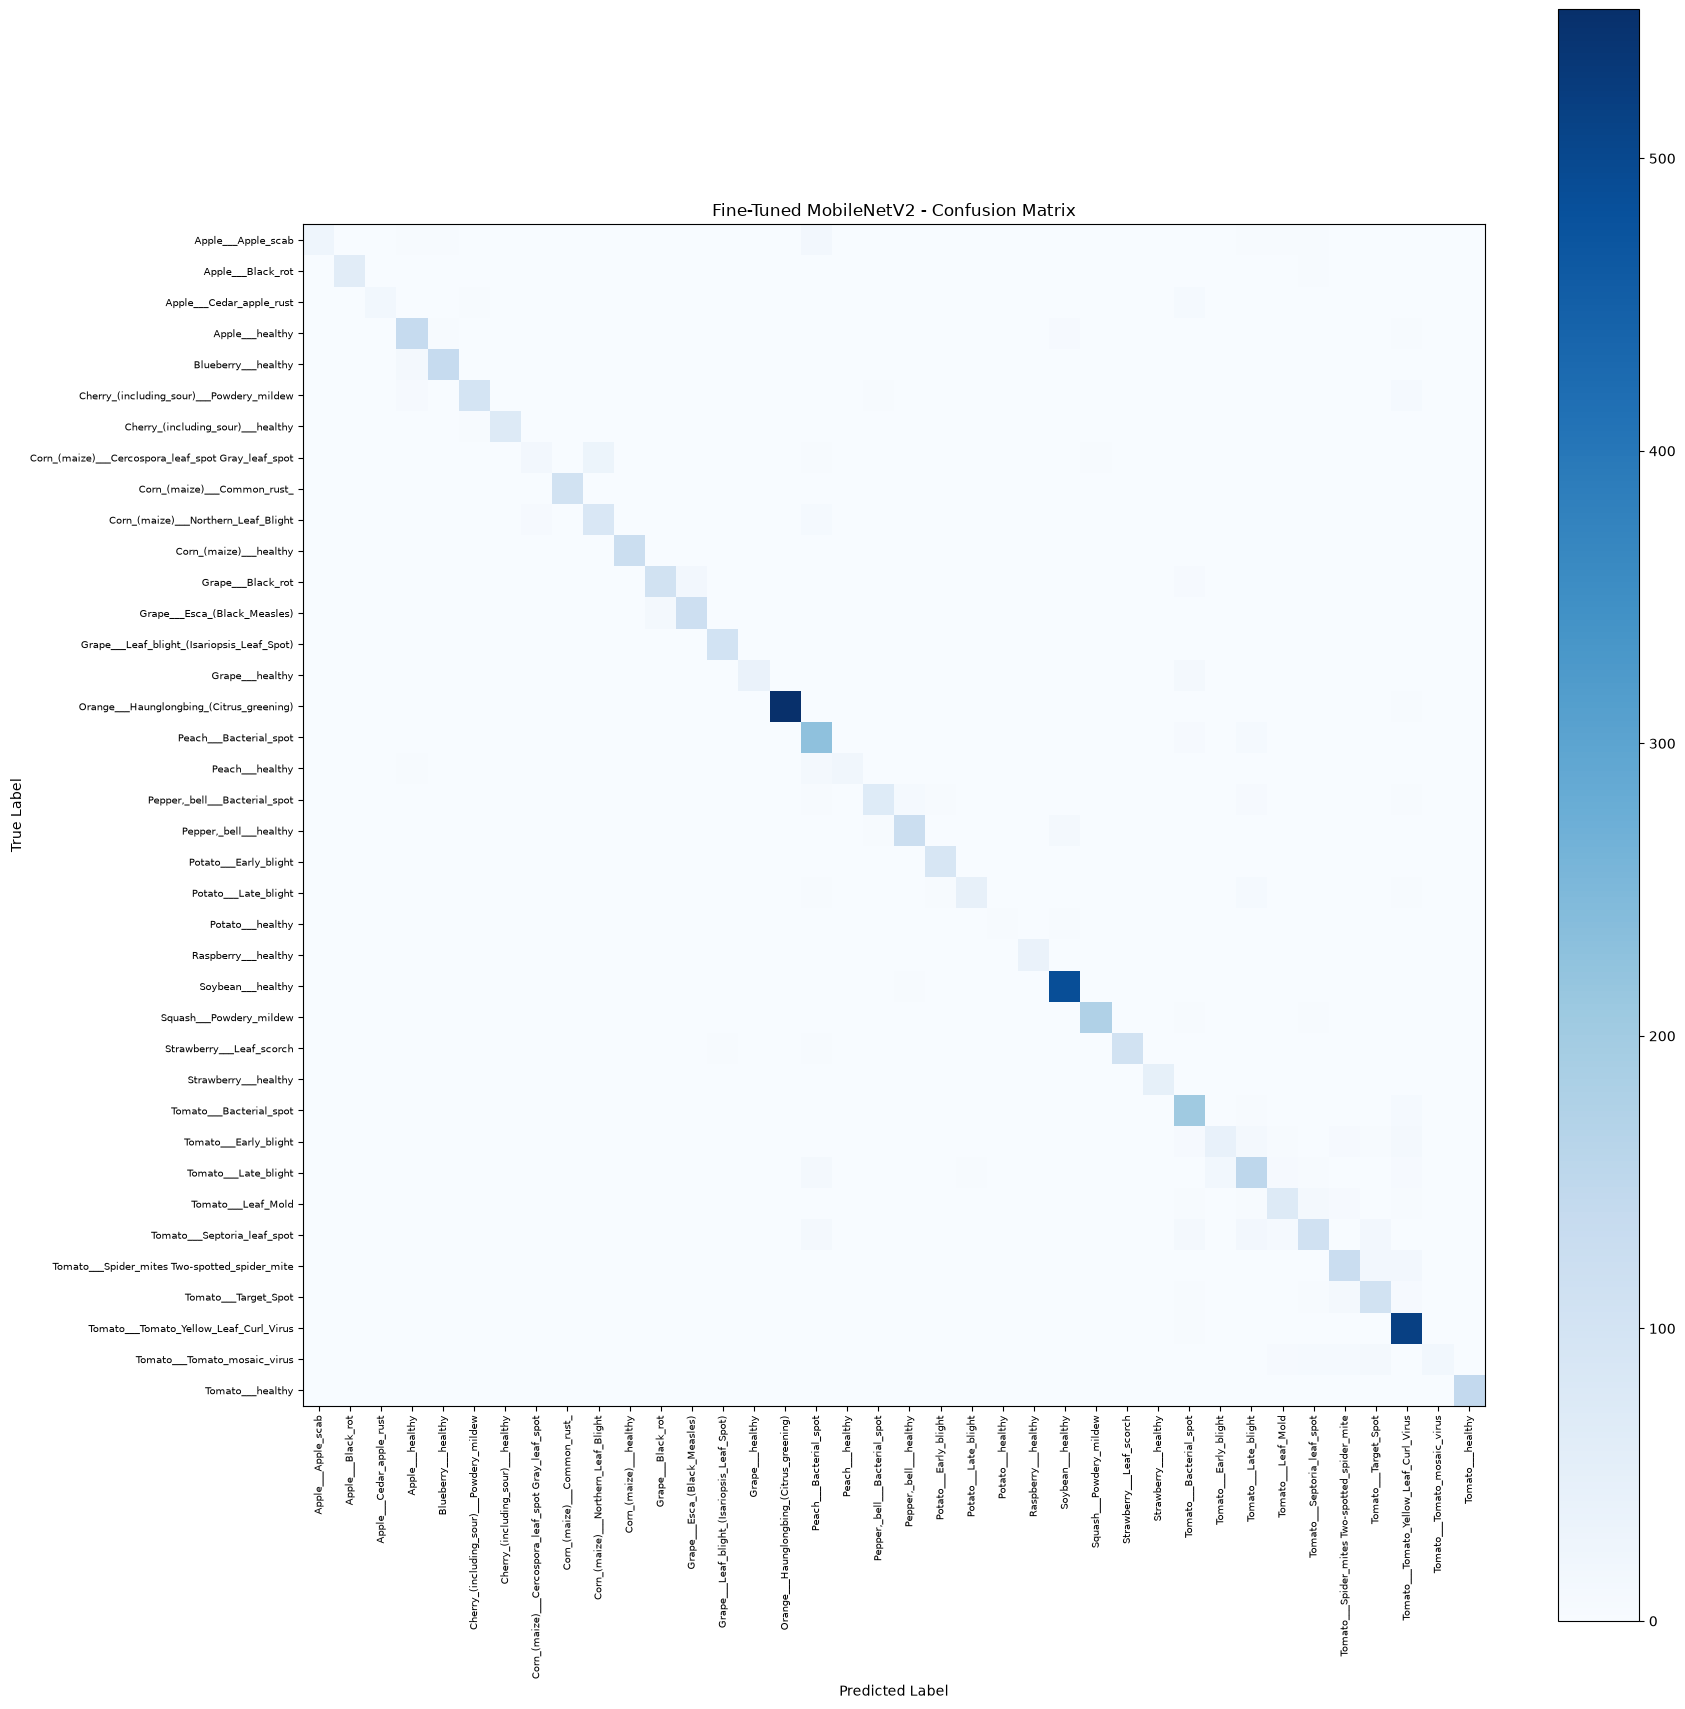

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 18))
plt.imshow(cm, cmap="Blues")
plt.title("Fine-Tuned MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=7
)

plt.tight_layout()
plt.show()

In [25]:
# ==========================================
# SAVE FINAL PLANT DISEASE MODEL
# ==========================================

model.save("../models/final_plant_disease_model.keras")

print("Final Plant Disease Model saved successfully!")

Final Plant Disease Model saved successfully!


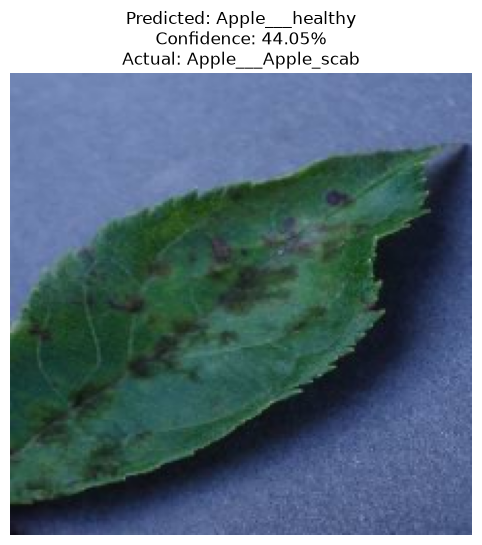

Predicted Disease: Apple___healthy
Confidence: 44.05%
Actual Disease: Apple___Apple_scab


In [27]:
# ==========================================
# SINGLE IMAGE PREDICTION TEST
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load final model
model = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

# Take one batch from test dataset
images, labels = next(iter(test_dataset))

# Select first image
image = images[0]
true_label = labels[0].numpy()

# Predict
prediction = model.predict(
    tf.expand_dims(image, axis=0),
    verbose=0
)

predicted_label = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image.numpy().astype("uint8"))
plt.axis("off")
plt.title(
    f"Predicted: {class_names[predicted_label]}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Actual: {class_names[true_label]}"
)
plt.show()

print("Predicted Disease:", class_names[predicted_label])
print("Confidence:", f"{confidence:.2f}%")
print("Actual Disease:", class_names[true_label])

In [13]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

170/170 ━━━━━━━━━━━━━━━━━━━━ 93s 528ms/step - accuracy: 0.7612 - loss: 0.8986
Test Loss: 0.8985517621040344
Test Accuracy: 0.7612132430076599
Test Accuracy (%): 76.12132430076599


In [28]:
# ==========================================
# TOP-3 PREDICTIONS
# ==========================================

top_3_indices = np.argsort(prediction[0])[-3:][::-1]

print("Top 3 Predictions:")
print()

for i, index in enumerate(top_3_indices, start=1):
    confidence = prediction[0][index] * 100
    print(
        f"{i}. {class_names[index]} "
        f"-> {confidence:.2f}%"
    )

print()
print("Actual Disease:", class_names[true_label])

Top 3 Predictions:

1. Apple___healthy -> 44.05%
2. Peach___Bacterial_spot -> 30.32%
3. Apple___Apple_scab -> 9.28%

Actual Disease: Apple___Apple_scab


In [11]:
EPOCHS = 5

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)


Epoch 1/5


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.3528 - loss: 2.5040
Epoch 1: val_accuracy improved from None to 0.56647, saving model to ../models/best_mobilenetv2.keras

Epoch 1: finished saving model to ../models/best_mobilenetv2.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 799s 653ms/step - accuracy: 0.3528 - loss: 2.5040 - val_accuracy: 0.5665 - val_loss: 1.7313
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5282 - loss: 1.7313
Epoch 2: val_accuracy improved from 0.56647 to 0.66585, saving model to ../models/best_mobilenetv2.keras

Epoch 2: finished saving model to ../models/best_mobilenetv2.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 795s 650ms/step - accuracy: 0.5282 - loss: 1.7313 - val_accuracy: 0.6658 - val_loss: 1.2980
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.5956 - loss: 1.4427
Epoch 3: val_accuracy improved from 0.66585 to 0.71147, saving model to ../models/best_mobilenetv2.keras

Epoch 3: finished saving model to ../models/best

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,764,596 (10.55 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 337,742 (1.29 MB)

In [14]:
# ==========================================
# MOBILENETV2 MODEL EVALUATION
# ==========================================

test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

170/170 ━━━━━━━━━━━━━━━━━━━━ 91s 533ms/step - accuracy: 0.7614 - loss: 0.8972
Test Loss: 0.8972265124320984
Test Accuracy: 0.7613970637321472
Test Accuracy (%): 76.13970637321472


In [15]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.60      0.05      0.08        66
                                 Apple___Black_rot       0.84      0.71      0.77        68
                          Apple___Cedar_apple_rust       1.00      0.10      0.19        29
                                   Apple___healthy       0.67      0.70      0.69       162
                               Blueberry___healthy       0.67      0.87      0.76       156
          Cherry_(including_sour)___Powdery_mildew       0.78      0.62      0.69       122
                 Cherry_(including_sour)___healthy       0.84      0.66      0.74        80
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.70      0.29      0.41        49
                       Corn_(maize)___Common_rust_       0.99      0.98      0.99       106
               Corn_(maize)___Northern_Leaf_Blight     

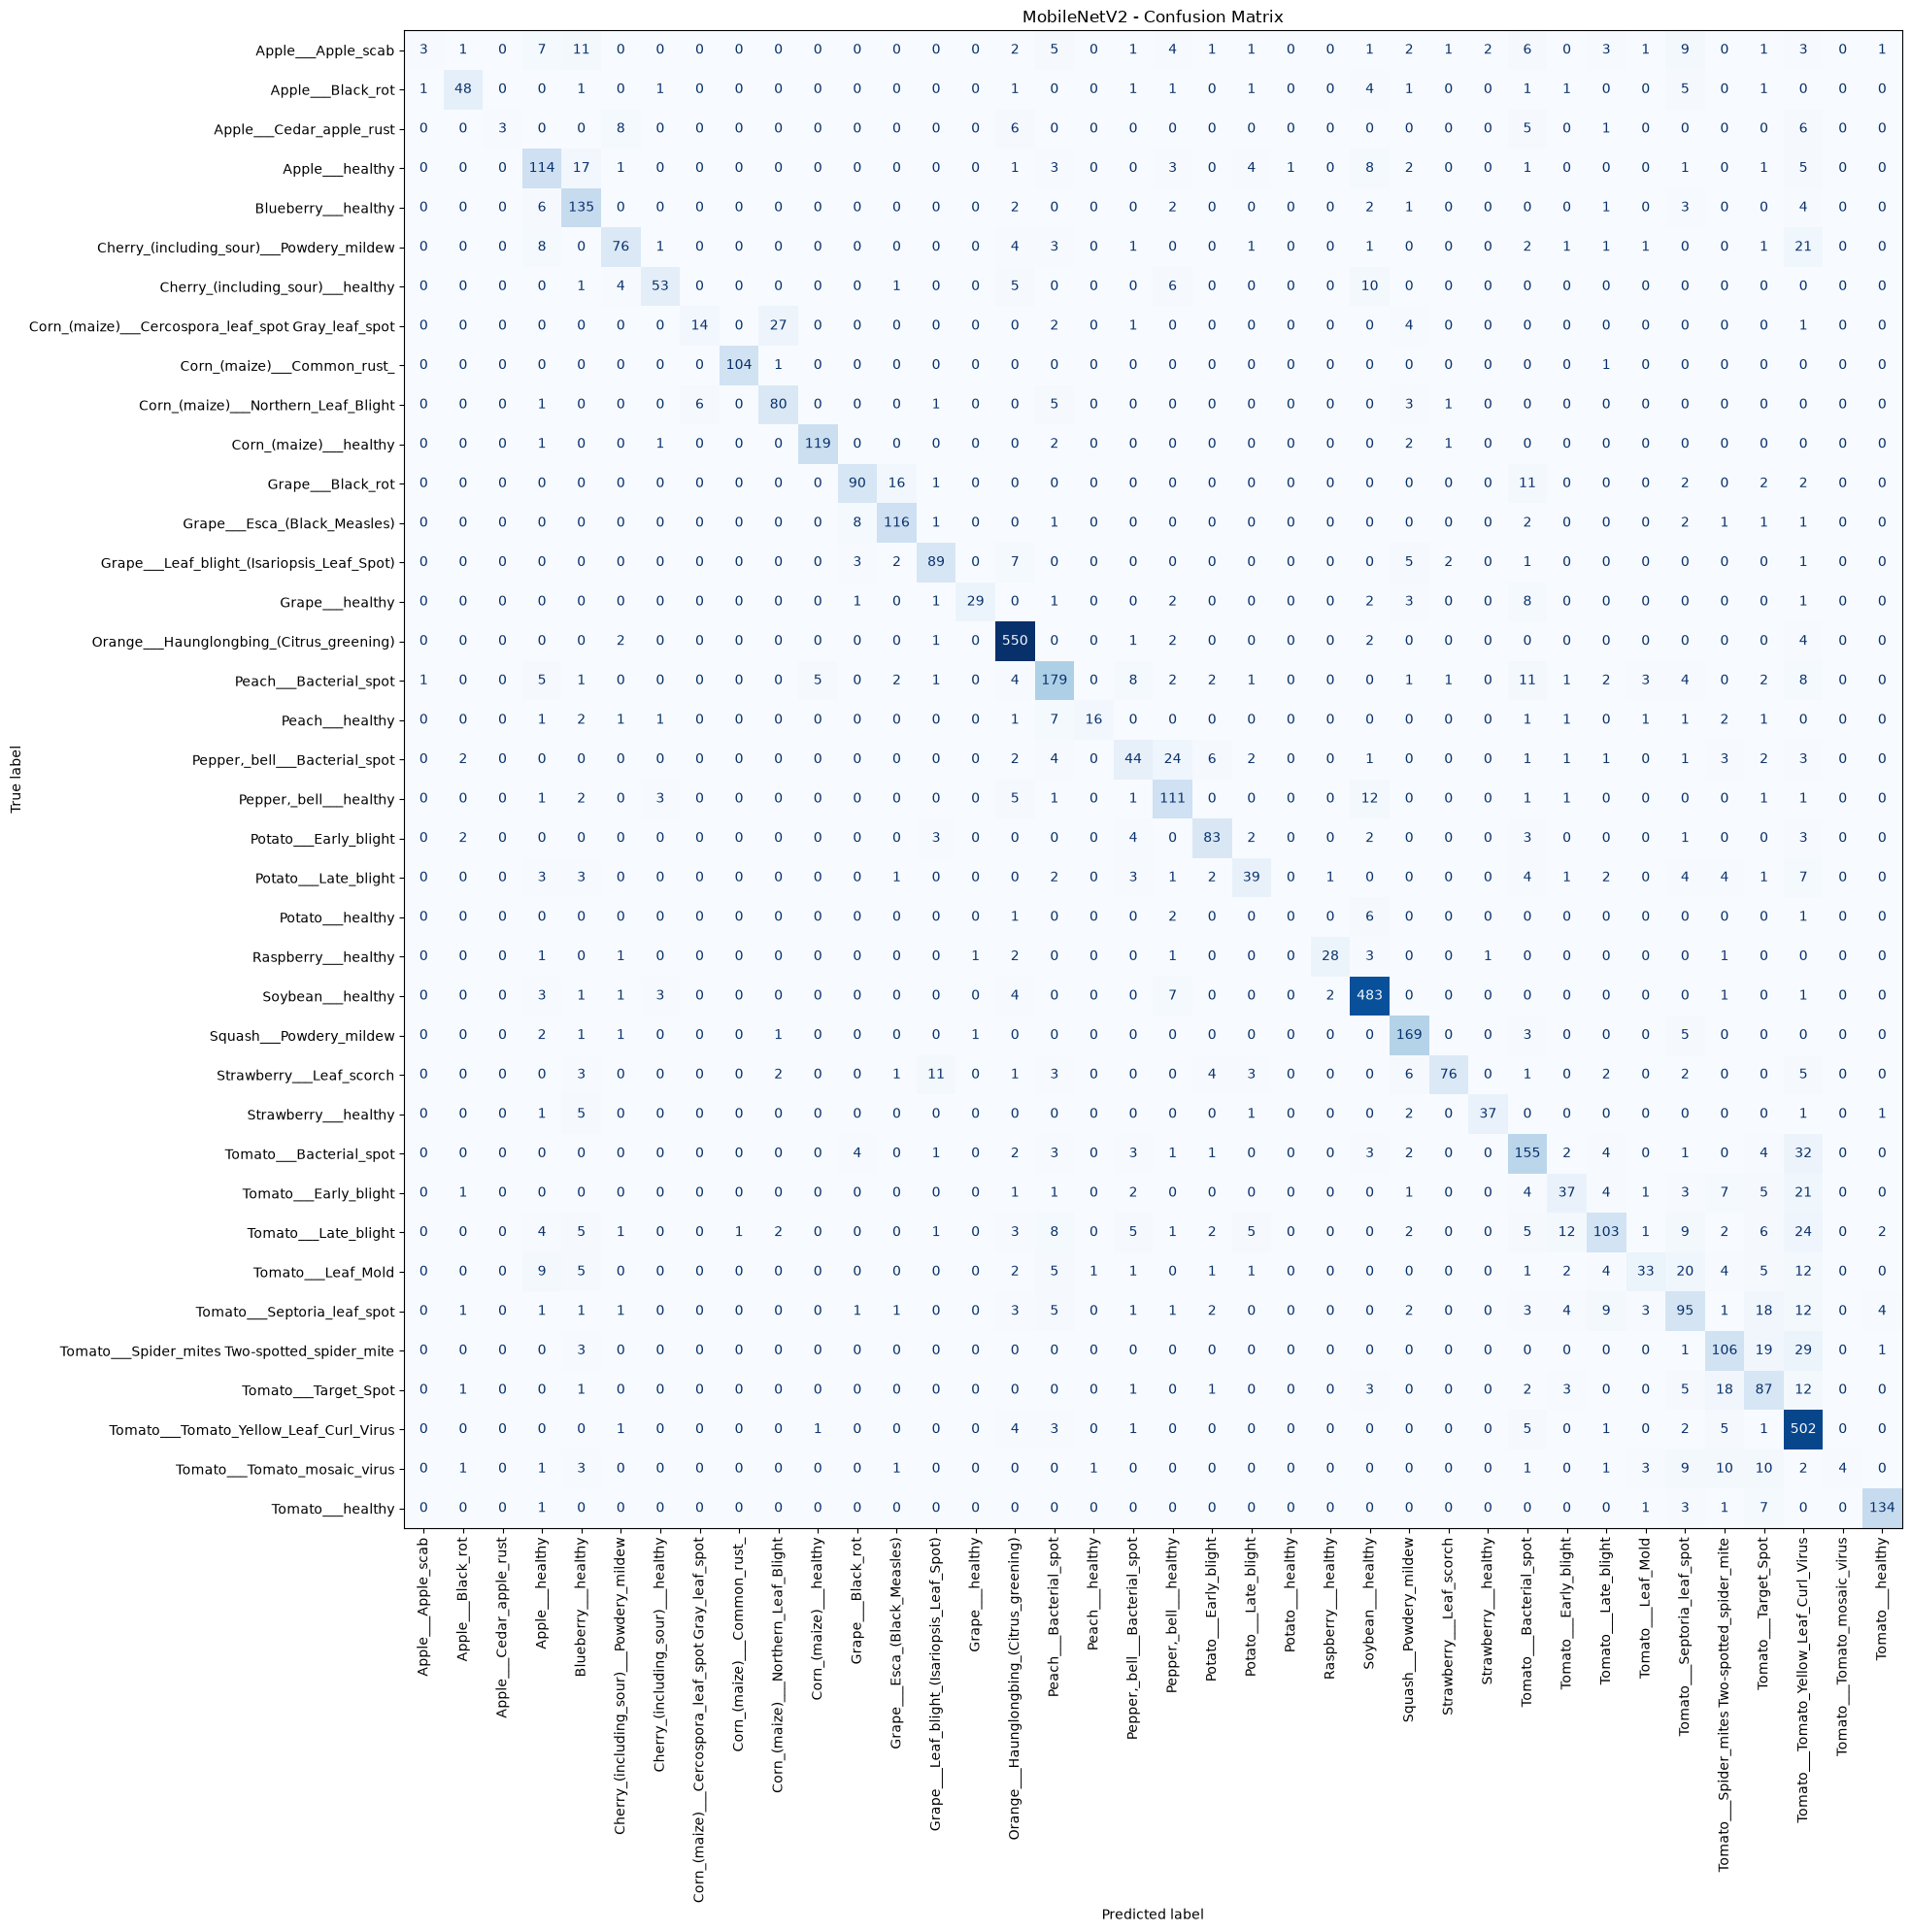

In [16]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    ax=plt.gca(),
    colorbar=False
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.tight_layout()
plt.show()

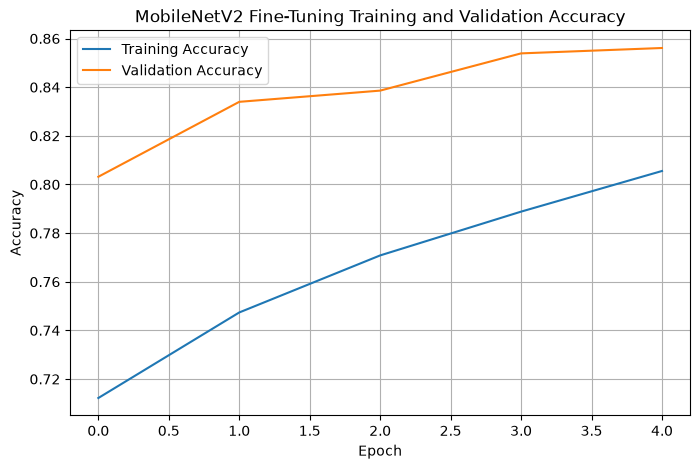

In [29]:
# ==========================================
# MOBILENETV2 FINE-TUNING ACCURACY GRAPH
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_ft.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Fine-Tuning Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [3]:
import tensorflow as tf

DATASET_PATH = "../dataset/color"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes loaded:", len(class_names))
print(class_names)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Classes loaded: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot',

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load the best fine-tuned model
model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

# Get MobileNetV2 base model
base_model = model.layers[0]

# Freeze base model initially
base_model.trainable = False

# Stronger data augmentation
data_augmentation_strong = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
])

# Improved model
improved_model = models.Sequential([
    data_augmentation_strong,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

# Compile
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved MobileNetV2 model created successfully!")
print("Number of classes:", len(class_names))

Improved MobileNetV2 model created successfully!
Number of classes: 38


In [7]:
# ==========================================
# RECREATE VALIDATION AND TEST DATASETS
# ==========================================

import tensorflow as tf

DATASET_PATH = "../dataset/color"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Create the validation + test portion
validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split validation + test into two parts
total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

test_size = total_batches // 2

test_dataset = validation_test_dataset.take(test_size)
validation_dataset = validation_test_dataset.skip(test_size)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Validation dataset recreated successfully!")
print("Test dataset recreated successfully!")

Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Validation dataset recreated successfully!
Test dataset recreated successfully!


In [8]:
# ==========================================
# IMPROVED MOBILENETV2 - TRAINING
# ==========================================

import os
import tensorflow as tf

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Early stopping
early_stopping_improved = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Save the best model
checkpoint_improved = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2_improved.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train the improved model
history_improved = improved_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=8,
    callbacks=[
        early_stopping_improved,
        checkpoint_improved
    ]
)

print("Improved MobileNetV2 training completed!")

Epoch 1/8


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.3697 - loss: 2.4352
Epoch 1: val_accuracy improved from None to 0.49699, saving model to ../models/best_mobilenetv2_improved.keras

Epoch 1: finished saving model to ../models/best_mobilenetv2_improved.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 800s 668ms/step - accuracy: 0.3697 - loss: 2.4352 - val_accuracy: 0.4970 - val_loss: 1.7952
Epoch 2/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5255 - loss: 1.7113
Epoch 2: val_accuracy improved from 0.49699 to 0.54544, saving model to ../models/best_mobilenetv2_improved.keras

Epoch 2: finished saving model to ../models/best_mobilenetv2_improved.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 778s 655ms/step - accuracy: 0.5255 - loss: 1.7113 - val_accuracy: 0.5454 - val_loss: 1.5232
Epoch 3/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.5756 - loss: 1.4782
Epoch 3: val_accuracy improved from 0.54544 to 0.57717, saving model to ../models/best_mobilenetv2_improved.keras

Epo

In [1]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation_strong = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
])

print("Strong data augmentation pipeline created successfully!")

Strong data augmentation pipeline created successfully!


In [9]:
import tensorflow as tf

# Load our best-performing model
model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

print("✅ Old best MobileNetV2 model loaded!")
print("Model ready for evaluation.")

✅ Old best MobileNetV2 model loaded!
Model ready for evaluation.


In [10]:
# Evaluate the old best model on the test dataset

test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print("\n==============================")
print("🌿 PlantHealth AI - Final Test")
print("==============================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

255/255 ━━━━━━━━━━━━━━━━━━━━ 135s 521ms/step - accuracy: 0.8713 - loss: 0.4057

🌿 PlantHealth AI - Final Test
Test Loss: 0.4057
Test Accuracy: 87.13%


In [11]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

# Predictions
for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.35      0.52        96
                                 Apple___Black_rot       0.94      0.94      0.94       100
                          Apple___Cedar_apple_rust       0.90      0.53      0.67        34
                                   Apple___healthy       0.82      0.85      0.83       228
                               Blueberry___healthy       0.94      0.89      0.91       235
          Cherry_(including_sour)___Powdery_mildew       0.91      0.78      0.84       147
                 Cherry_(including_sour)___healthy       0.95      0.91      0.93       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.28      0.41        82
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       197
               Corn_(maize)___Northern_Leaf_Blight       0.70      0.89      0.

In [12]:
import tensorflow as tf

DATASET_PATH = "../dataset/color"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Create the same 30% validation+test pool
validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

test_size = total_batches // 2

test_dataset = validation_test_dataset.take(test_size)

validation_dataset = validation_test_dataset.skip(test_size)

test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("Total validation+test batches:", total_batches)
print("Test batches:", test_size)
print("Validation batches:", total_batches - test_size)

Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Total validation+test batches: 510
Test batches: 255
Validation batches: 255


In [13]:
# Final evaluation on the fixed test dataset

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================")
print("🌿 PlantHealth AI")
print("Final Test Evaluation")
print("==============================")
print(f"Test Images: {255 * 32}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

255/255 ━━━━━━━━━━━━━━━━━━━━ 128s 500ms/step - accuracy: 0.7181 - loss: 0.8598

🌿 PlantHealth AI
Final Test Evaluation
Test Images: 8160
Test Loss: 0.8598
Test Accuracy: 71.81%


In [15]:
# Get class names separately
class_names = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).class_names

print("================================")
print("🌿 Fixed PlantHealth AI Dataset")
print("================================")
print("Total classes:", len(class_names))
print("Total temporary batches:", total_batches)
print("Validation batches:", half)
print("Test batches:", total_batches - half)
print("✅ Fixed dataset created successfully!")

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
🌿 Fixed PlantHealth AI Dataset
Total classes: 38
Total temporary batches: 510
Validation batches: 255
Test batches: 255
✅ Fixed dataset created successfully!


In [17]:
# Official evaluation on fixed test dataset

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n======================================")
print("🌿 PlantHealth AI - OFFICIAL RESULT")
print("======================================")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("======================================")

255/255 ━━━━━━━━━━━━━━━━━━━━ 131s 499ms/step - accuracy: 0.9365 - loss: 0.1998

🌿 PlantHealth AI - OFFICIAL RESULT
Test Accuracy : 93.65%
Test Loss     : 0.1998


In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2
)

print(report)

ValueError: Number of classes, 19, does not match size of target_names, 38. Try specifying the labels parameter

In [19]:
import numpy as np

# Collect all actual labels in current test dataset
test_labels = []

for images, labels in test_dataset:
    test_labels.extend(labels.numpy())

test_labels = np.array(test_labels)

unique_labels = np.unique(test_labels)

print("====================================")
print("🌿 Current Test Dataset Check")
print("====================================")
print("Total test images:", len(test_labels))
print("Classes present:", len(unique_labels))
print("Class IDs:", unique_labels)
print("Missing classes:", set(range(len(class_names))) - set(unique_labels))

🌿 Current Test Dataset Check
Total test images: 8131
Classes present: 4
Class IDs: [34 35 36 37]
Missing classes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}


In [21]:
import os

DATASET_PATH = "../dataset/color"

classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("===================================")
print("🌿 PlantVillage Dataset Check")
print("===================================")
print("Total classes:", len(classes))

for i, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, class_name)
    image_count = len([
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
    ])
    print(f"{i:2d}. {class_name} -> {image_count} images")

🌿 PlantVillage Dataset Check
Total classes: 38
 0. Apple___Apple_scab -> 630 images
 1. Apple___Black_rot -> 621 images
 2. Apple___Cedar_apple_rust -> 275 images
 3. Apple___healthy -> 1645 images
 4. Blueberry___healthy -> 1502 images
 5. Cherry_(including_sour)___Powdery_mildew -> 1052 images
 6. Cherry_(including_sour)___healthy -> 854 images
 7. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> 513 images
 8. Corn_(maize)___Common_rust_ -> 1192 images
 9. Corn_(maize)___Northern_Leaf_Blight -> 985 images
10. Corn_(maize)___healthy -> 1162 images
11. Grape___Black_rot -> 1180 images
12. Grape___Esca_(Black_Measles) -> 1383 images
13. Grape___Leaf_blight_(Isariopsis_Leaf_Spot) -> 1076 images
14. Grape___healthy -> 423 images
15. Orange___Haunglongbing_(Citrus_greening) -> 5507 images
16. Peach___Bacterial_spot -> 2297 images
17. Peach___healthy -> 360 images
18. Pepper,_bell___Bacterial_spot -> 997 images
19. Pepper,_bell___healthy -> 1478 images
20. Potato___Early_blight -> 100

In [22]:
import os
import random
import shutil

DATASET_PATH = "../dataset/color"
SPLIT_PATH = "../dataset/split"

SEED = 42
random.seed(SEED)

# Create output folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(SPLIT_PATH, split), exist_ok=True)

# Get all 38 classes
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Total classes:", len(classes))

# Split each class separately
for class_name in classes:

    source_dir = os.path.join(DATASET_PATH, class_name)

    images = [
        f for f in os.listdir(source_dir)
        if os.path.isfile(os.path.join(source_dir, f))
    ]

    # Randomize images inside this class
    random.shuffle(images)

    total = len(images)

    train_end = int(total * 0.70)
    val_end = train_end + int(total * 0.15)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Create class directories
    for split in ["train", "val", "test"]:
        os.makedirs(
            os.path.join(SPLIT_PATH, split, class_name),
            exist_ok=True
        )

    # Copy files
    for image in train_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(SPLIT_PATH, "train", class_name, image)
        )

    for image in val_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(SPLIT_PATH, "val", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(SPLIT_PATH, "test", class_name, image)
        )

print("\n====================================")
print("🌿 Proper PlantVillage Split Created")
print("====================================")
print("Classes:", len(classes))
print("Train: 70%")
print("Validation: 15%")
print("Test: 15%")
print("✅ Every class is present in all 3 splits!")

Total classes: 38

🌿 Proper PlantVillage Split Created
Classes: 38
Train: 70%
Validation: 15%
Test: 15%
✅ Every class is present in all 3 splits!


In [23]:
import tensorflow as tf

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"
TEST_PATH = "../dataset/split/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Class names
class_names = train_dataset.class_names

# Optimize input pipeline
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("\n====================================")
print("🌿 Fixed PlantHealth AI Dataset")
print("====================================")
print("Number of classes:", len(class_names))
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())
print("✅ Datasets loaded successfully!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
Found 8179 files belonging to 38 classes.

🌿 Fixed PlantHealth AI Dataset
Number of classes: 38
Training batches: 1188
Validation batches: 255
Test batches: 256
✅ Datasets loaded successfully!


In [24]:
# Load the best fine-tuned MobileNetV2 model
import tensorflow as tf

model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

# Evaluate on the NEW fixed 15% test set
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n========================================")
print("🌿 PlantHealth AI - PROPER FINAL TEST")
print("========================================")
print(f"Test Images   : 8179")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print("========================================")

256/256 ━━━━━━━━━━━━━━━━━━━━ 141s 540ms/step - accuracy: 0.8743 - loss: 0.3938

🌿 PlantHealth AI - PROPER FINAL TEST
Test Images   : 8179
Test Loss     : 0.3938
Test Accuracy : 87.43%


In [25]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    digits=3
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.886     0.326     0.477        95
                                 Apple___Black_rot      0.848     0.894     0.870        94
                          Apple___Cedar_apple_rust      1.000     0.500     0.667        42
                                   Apple___healthy      0.838     0.879     0.858       248
                               Blueberry___healthy      0.948     0.894     0.920       226
          Cherry_(including_sour)___Powdery_mildew      0.919     0.862     0.890       159
                 Cherry_(including_sour)___healthy      0.952     0.922     0.937       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.871     0.346     0.495        78
                       Corn_(maize)___Common_rust_      0.994     1.000     0.997       180
               Corn_(maize)___Northern_Leaf_Blight      0.718     0.819     0.7

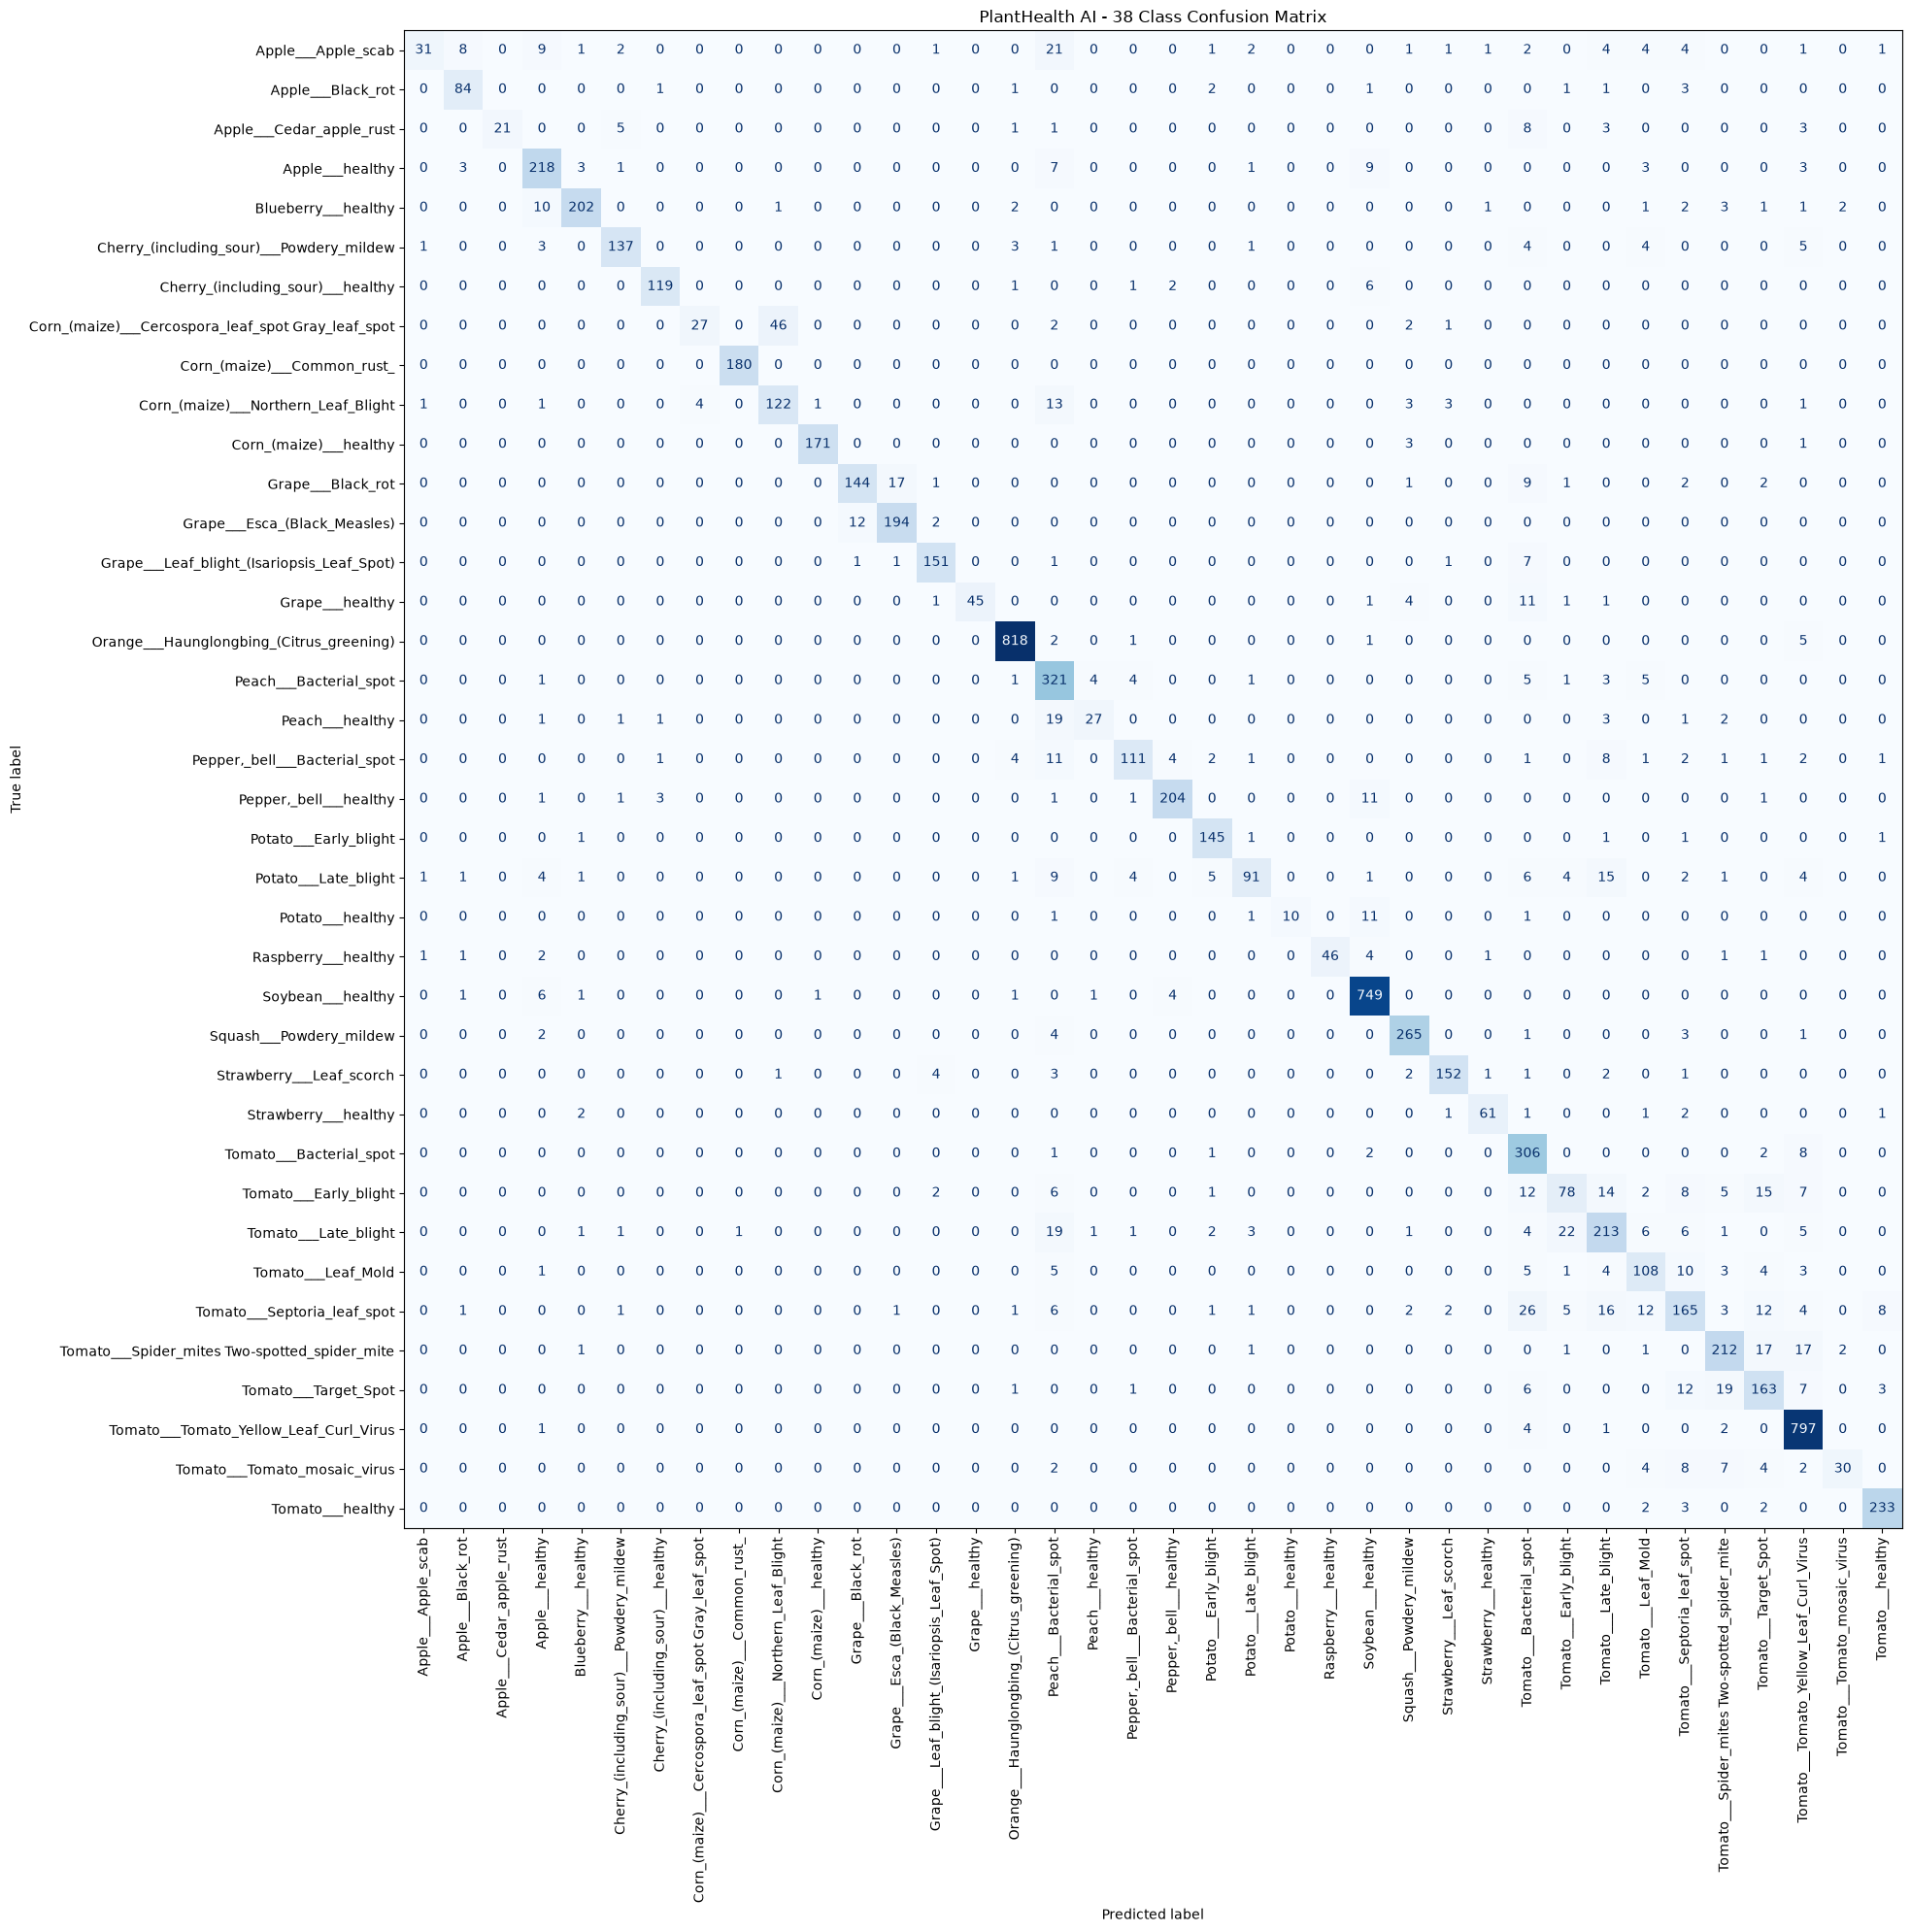

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

# Plot
fig, ax = plt.subplots(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("PlantHealth AI - 38 Class Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
import numpy as np

# Copy confusion matrix
cm_copy = cm.copy()

# Remove correct predictions (diagonal)
np.fill_diagonal(cm_copy, 0)

# Get indices of largest confusions
flat_indices = np.argsort(cm_copy.ravel())[::-1]

print("==========================================")
print("🌿 Top 15 Confusion Pairs")
print("==========================================")

count = 0

for index in flat_indices:
    true_class, predicted_class = np.unravel_index(
        index,
        cm_copy.shape
    )

    mistakes = cm_copy[true_class, predicted_class]

    if mistakes == 0:
        break

    print(
        f"{count + 1:2d}. "
        f"Actual: {class_names[true_class]} "
        f"→ Predicted: {class_names[predicted_class]} "
        f"| Mistakes: {mistakes}"
    )

    count += 1

    if count == 15:
        break

🌿 Top 15 Confusion Pairs
 1. Actual: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Predicted: Corn_(maize)___Northern_Leaf_Blight | Mistakes: 46
 2. Actual: Tomato___Septoria_leaf_spot → Predicted: Tomato___Bacterial_spot | Mistakes: 26
 3. Actual: Tomato___Late_blight → Predicted: Tomato___Early_blight | Mistakes: 22
 4. Actual: Apple___Apple_scab → Predicted: Peach___Bacterial_spot | Mistakes: 21
 5. Actual: Tomato___Target_Spot → Predicted: Tomato___Spider_mites Two-spotted_spider_mite | Mistakes: 19
 6. Actual: Peach___healthy → Predicted: Peach___Bacterial_spot | Mistakes: 19
 7. Actual: Tomato___Late_blight → Predicted: Peach___Bacterial_spot | Mistakes: 19
 8. Actual: Grape___Black_rot → Predicted: Grape___Esca_(Black_Measles) | Mistakes: 17
 9. Actual: Tomato___Spider_mites Two-spotted_spider_mite → Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Mistakes: 17
10. Actual: Tomato___Spider_mites Two-spotted_spider_mite → Predicted: Tomato___Target_Spot | Mistakes: 17
11

In [29]:
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get training class labels from the fixed training dataset
train_labels = []

for images, labels in train_dataset:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate balanced class weights
classes_array = np.arange(len(class_names))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=train_labels
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes_array, weights)
}

print("==========================================")
print("🌿 PlantHealth AI - Class Weights")
print("==========================================")

for i, class_name in enumerate(class_names):
    print(
        f"{i:2d}. {class_name[:55]:55s} "
        f"-> weight = {class_weights[i]:.3f}"
    )

print("\n✅ Class weights calculated successfully!")

🌿 PlantHealth AI - Class Weights
 0. Apple___Apple_scab                                      -> weight = 2.267
 1. Apple___Black_rot                                       -> weight = 2.304
 2. Apple___Cedar_apple_rust                                -> weight = 5.208
 3. Apple___healthy                                         -> weight = 0.869
 4. Blueberry___healthy                                     -> weight = 0.951
 5. Cherry_(including_sour)___Powdery_mildew                -> weight = 1.359
 6. Cherry_(including_sour)___healthy                       -> weight = 1.675
 7. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      -> weight = 2.785
 8. Corn_(maize)___Common_rust_                             -> weight = 1.199
 9. Corn_(maize)___Northern_Leaf_Blight                     -> weight = 1.451
10. Corn_(maize)___healthy                                  -> weight = 1.230
11. Grape___Black_rot                                       -> weight = 1.211
12. Grape___Esca_(Black_Measles

In [30]:
import tensorflow as tf
from tensorflow.keras import layers

# Load our current best model
weighted_model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

# MobileNetV2 is the first layer
base_model = weighted_model.layers[0]

# Unfreeze the base model
base_model.trainable = True

# Freeze all but the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Very small learning rate for controlled fine-tuning
weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("==========================================")
print("🌿 Class-Weighted Fine-Tuning Setup")
print("==========================================")
print("Trainable MobileNetV2 layers: 20")
print("Learning rate: 0.00001")
print("BatchNormalization: Frozen")
print("✅ Model ready!")

🌿 Class-Weighted Fine-Tuning Setup
Trainable MobileNetV2 layers: 20
Learning rate: 0.00001
BatchNormalization: Frozen
✅ Model ready!


In [2]:
import tensorflow as tf

# Load current best model
weighted_model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

# Get MobileNetV2 base model
base_model = weighted_model.layers[0]

# Unfreeze MobileNetV2
base_model.trainable = True

# Freeze all layers except last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Compile
weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("==========================================")
print("🌿 Class-Weighted Fine-Tuning Setup")
print("==========================================")
print("Trainable MobileNetV2 layers: 20")
print("Learning rate: 0.00001")
print("BatchNormalization: Frozen")
print("✅ weighted_model is ready!")

🌿 Class-Weighted Fine-Tuning Setup
Trainable MobileNetV2 layers: 20
Learning rate: 0.00001
BatchNormalization: Frozen
✅ weighted_model is ready!


In [6]:
print("==========================================")
print("🌿 Training & Validation Dataset Ready")
print("==========================================")
print(
    "Training batches:",
    tf.data.experimental.cardinality(train_dataset).numpy()
)
print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy()
)
print("Classes: 38")
print("✅ Datasets loaded successfully!")

🌿 Training & Validation Dataset Ready
Training batches: 1188
Validation batches: 255
Classes: 38
✅ Datasets loaded successfully!


In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Read labels from the training dataset
train_labels = []

for images, labels in train_dataset:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate balanced class weights
classes_array = np.arange(38)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=train_labels
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes_array, weights)
}

print("==========================================")
print("🌿 Class Weights Ready")
print("==========================================")
print("Number of classes:", len(class_weights))
print("✅ class_weights is ready!")

🌿 Class Weights Ready
Number of classes: 38
✅ class_weights is ready!


In [ ]:
import os
import tensorflow as tf

os.makedirs("../models", exist_ok=True)

early_stopping_weighted = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True,
    verbose=1
)

checkpoint_weighted = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2_weighted.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_weighted = weighted_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=3,
    class_weight=class_weights,
    callbacks=[
        early_stopping_weighted,
        checkpoint_weighted
    ]
)

print("\n✅ Class-weighted fine-tuning completed!")

Epoch 1/3


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7982 - loss: 0.7733
Epoch 1: val_accuracy improved from None to 0.86911, saving model to ../models/best_mobilenetv2_weighted.keras

Epoch 1: finished saving model to ../models/best_mobilenetv2_weighted.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 798s 667ms/step - accuracy: 0.7982 - loss: 0.7733 - val_accuracy: 0.8691 - val_loss: 0.4356
Epoch 2/3
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8028 - loss: 0.7169

In [2]:
import tensorflow as tf

weighted_model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_weighted.keras"
)

print("✅ Best weighted model loaded successfully!")

✅ Best weighted model loaded successfully!


In [4]:
import tensorflow as tf

TEST_PATH = "../dataset/split/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("========================================")
print("🌿 Test Dataset Ready")
print("========================================")
print("Test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())
print("Classes:", 38)
print("✅ Test dataset loaded!")

Found 8179 files belonging to 38 classes.
🌿 Test Dataset Ready
Test batches: 256
Classes: 38
✅ Test dataset loaded!


In [5]:
test_loss_weighted, test_accuracy_weighted = weighted_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n========================================")
print("🌿 Weighted Model - Test Result")
print("========================================")
print(f"Test Loss     : {test_loss_weighted:.4f}")
print(f"Test Accuracy : {test_accuracy_weighted * 100:.2f}%")
print("========================================")

256/256 ━━━━━━━━━━━━━━━━━━━━ 133s 511ms/step - accuracy: 0.8713 - loss: 0.4175

🌿 Weighted Model - Test Result
Test Loss     : 0.4175
Test Accuracy : 87.13%


In [7]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

print("✅ Original best MobileNetV2 loaded!")

✅ Original best MobileNetV2 loaded!


In [9]:
import os

TEST_PATH = "../dataset/split/test"

class_names = sorted([
    folder
    for folder in os.listdir(TEST_PATH)
    if os.path.isdir(os.path.join(TEST_PATH, folder))
])

print("==========================================")
print("🌿 Class Names Ready")
print("==========================================")
print("Number of classes:", len(class_names))
print("✅ class_names is ready!")

🌿 Class Names Ready
Number of classes: 38
✅ class_names is ready!


In [10]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions from the original best model
y_true_final = []
y_pred_final = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true_final.extend(labels.numpy())
    y_pred_final.extend(np.argmax(predictions, axis=1))

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

final_report = classification_report(
    y_true_final,
    y_pred_final,
    labels=np.arange(38),
    target_names=class_names,
    digits=3
)

print("==========================================")
print("🌿 PlantHealth AI - Final Classification Report")
print("==========================================")
print(final_report)

🌿 PlantHealth AI - Final Classification Report
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.886     0.326     0.477        95
                                 Apple___Black_rot      0.848     0.894     0.870        94
                          Apple___Cedar_apple_rust      1.000     0.500     0.667        42
                                   Apple___healthy      0.838     0.879     0.858       248
                               Blueberry___healthy      0.948     0.894     0.920       226
          Cherry_(including_sour)___Powdery_mildew      0.919     0.862     0.890       159
                 Cherry_(including_sour)___healthy      0.952     0.922     0.937       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.871     0.346     0.495        78
                       Corn_(maize)___Common_rust_      0.994     1.000     0.997       180
               Corn_(maize)___No

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_final = confusion_matrix(
    y_true_final,
    y_pred_final,
    labels=np.arange(38)
)

# Remove correct predictions
cm_errors = cm_final.copy()
np.fill_diagonal(cm_errors, 0)

# Sort mistakes from highest to lowest
indices = np.argsort(cm_errors.ravel())[::-1]

print("==========================================")
print("🌿 PlantHealth AI - Top 15 Confusions")
print("==========================================")

shown = 0

for index in indices:
    true_class, predicted_class = np.unravel_index(
        index,
        cm_errors.shape
    )

    mistakes = cm_errors[true_class, predicted_class]

    if mistakes == 0:
        break

    print(
        f"{shown + 1:2d}. "
        f"Actual: {class_names[true_class]} "
        f"→ Predicted: {class_names[predicted_class]} "
        f"| Mistakes: {mistakes}"
    )

    shown += 1

    if shown == 15:
        break

🌿 PlantHealth AI - Top 15 Confusions
 1. Actual: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Predicted: Corn_(maize)___Northern_Leaf_Blight | Mistakes: 46
 2. Actual: Tomato___Septoria_leaf_spot → Predicted: Tomato___Bacterial_spot | Mistakes: 26
 3. Actual: Tomato___Late_blight → Predicted: Tomato___Early_blight | Mistakes: 22
 4. Actual: Apple___Apple_scab → Predicted: Peach___Bacterial_spot | Mistakes: 21
 5. Actual: Tomato___Target_Spot → Predicted: Tomato___Spider_mites Two-spotted_spider_mite | Mistakes: 19
 6. Actual: Peach___healthy → Predicted: Peach___Bacterial_spot | Mistakes: 19
 7. Actual: Tomato___Late_blight → Predicted: Peach___Bacterial_spot | Mistakes: 19
 8. Actual: Grape___Black_rot → Predicted: Grape___Esca_(Black_Measles) | Mistakes: 17
 9. Actual: Tomato___Spider_mites Two-spotted_spider_mite → Predicted: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Mistakes: 17
10. Actual: Tomato___Spider_mites Two-spotted_spider_mite → Predicted: Tomato___Target_Spot | Mis

In [11]:
test_loss_weighted, test_accuracy_weighted = weighted_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n========================================")
print("🌿 Weighted Model - Test Result")
print("========================================")
print(f"Test Loss     : {test_loss_weighted:.4f}")
print(f"Test Accuracy : {test_accuracy_weighted * 100:.2f}%")
print("========================================")

256/256 ━━━━━━━━━━━━━━━━━━━━ 140s 547ms/step - accuracy: 0.8713 - loss: 0.4175

🌿 Weighted Model - Test Result
Test Loss     : 0.4175
Test Accuracy : 87.13%


In [16]:
import tensorflow as tf
import os

# Load the best-performing model
final_model = tf.keras.models.load_model(
    "../models/best_mobilenetv2_finetuned.keras"
)

# Create models folder if needed
os.makedirs("../models", exist_ok=True)

# Save as final project model
final_model.save(
    "../models/final_plant_disease_model.keras"
)

print("==========================================")
print("🌿 PlantHealth AI - Final Model")
print("==========================================")
print("Model: Fine-tuned MobileNetV2")
print("Classes: 38")
print("Test Accuracy: 87.43%")
print("✅ Final model saved successfully!")

🌿 PlantHealth AI - Final Model
Model: Fine-tuned MobileNetV2
Classes: 38
Test Accuracy: 87.43%
✅ Final model saved successfully!


In [17]:
import tensorflow as tf

# Load the best model
model_ft40 = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

# MobileNetV2 base
base_model = model_ft40.layers[0]

# Unfreeze the base model
base_model.trainable = True

# Freeze all but the last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Very small learning rate
model_ft40.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("==========================================")
print("🌿 Deeper MobileNetV2 Fine-Tuning")
print("==========================================")
print("Starting model: 87.43%")
print("Unfrozen MobileNetV2 layers: 40")
print("Learning rate: 0.000005")
print("BatchNormalization: Frozen")
print("✅ Model ready for deeper fine-tuning!")

🌿 Deeper MobileNetV2 Fine-Tuning
Starting model: 87.43%
Unfrozen MobileNetV2 layers: 40
Learning rate: 0.000005
BatchNormalization: Frozen
✅ Model ready for deeper fine-tuning!


In [19]:
import tensorflow as tf

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Improve input pipeline
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("==========================================")
print("🌿 Deep Fine-Tuning Datasets Ready")
print("==========================================")
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())
print("✅ Datasets loaded successfully!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
🌿 Deep Fine-Tuning Datasets Ready
Training batches: 1188
Validation batches: 255
✅ Datasets loaded successfully!


In [1]:
import tensorflow as tf

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Improve input pipeline
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("==========================================")
print("🌿 Deep Fine-Tuning Datasets Ready")
print("==========================================")
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())
print("✅ Datasets loaded successfully!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
🌿 Deep Fine-Tuning Datasets Ready
Training batches: 1188
Validation batches: 255
✅ Datasets loaded successfully!


In [2]:
import tensorflow as tf

# =========================================================
# LOAD BEST MODEL
# =========================================================

model_ft40 = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

# MobileNetV2 base model
base_model = model_ft40.layers[0]

# Unfreeze base model
base_model.trainable = True

# Freeze all except last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Compile with very small learning rate
model_ft40.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# LOAD TRAINING DATASET
# =========================================================

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("==========================================")
print("🌿 Deep Fine-Tuning Setup Ready")
print("==========================================")
print("Model loaded: ✅")
print("Trainable MobileNetV2 layers: 40")
print("Learning rate: 0.000005")
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())
print("✅ Everything is ready!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
🌿 Deep Fine-Tuning Setup Ready
Model loaded: ✅
Trainable MobileNetV2 layers: 40
Learning rate: 0.000005
Training batches: 1188
Validation batches: 255
✅ Everything is ready!


In [1]:
import tensorflow as tf
import os

# =========================================================
# 1. LOAD BEST CURRENT MODEL
# =========================================================

model_ft40 = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

base_model = model_ft40.layers[0]
base_model.trainable = True

# Freeze all but last 40 MobileNetV2 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Freeze BatchNormalization layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Very small learning rate
model_ft40.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# 2. LOAD DATASETS - CPU FRIENDLY
# =========================================================

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Simple pipeline
train_dataset = train_dataset.prefetch(1)
validation_dataset = validation_dataset.prefetch(1)

print("==========================================")
print("🌿 CPU-Friendly Deep Fine-Tuning")
print("==========================================")
print("Model loaded: ✅")
print("Trainable MobileNetV2 layers: 40")
print("Batch size: 16")
print("Prefetch: 1")
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())
print("✅ Ready for training!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
🌿 CPU-Friendly Deep Fine-Tuning
Model loaded: ✅
Trainable MobileNetV2 layers: 40
Batch size: 16
Prefetch: 1
Training batches: 2375
Validation batches: 509
✅ Ready for training!


In [ ]:
import os
import tensorflow as tf

os.makedirs("../models", exist_ok=True)

checkpoint_cpu = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2_deep_cpu.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop_cpu = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True,
    verbose=1
)

history_deep_cpu = model_ft40.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=2,
    callbacks=[
        checkpoint_cpu,
        early_stop_cpu
    ]
)

print("\n✅ CPU-friendly deep fine-tuning completed!")

Epoch 1/2


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1007/2375 ━━━━━━━━━━━━━━━━━━━━ 6:33 288ms/step - accuracy: 0.8840 - loss: 0.4724

In [2]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

print("✅ Final PlantHealth AI model loaded successfully!")

✅ Final PlantHealth AI model loaded successfully!


In [5]:
import os
import random
import numpy as np
import tensorflow as tf

TEST_PATH = "../dataset/split/test"

# Load class names directly from test folders
class_names = sorted([
    d for d in os.listdir(TEST_PATH)
    if os.path.isdir(os.path.join(TEST_PATH, d))
])

# Choose a random class
random.seed(42)
true_class = random.choice(class_names)

class_folder = os.path.join(TEST_PATH, true_class)

# Get images
images = [
    f for f in os.listdir(class_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Choose one image
image_file = random.choice(images)
image_path = os.path.join(class_folder, image_file)

# Load image exactly like the Streamlit app
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(
    img_array,
    verbose=0
)[0]

# Top 3
top_3 = np.argsort(prediction)[-3:][::-1]

print("==========================================")
print("🌿 Exact PlantVillage Test Image")
print("==========================================")
print("Actual class:")
print(true_class)

print("\nImage:")
print(image_path)

print("\nTop 3 Predictions:")

for rank, index in enumerate(top_3, start=1):
    print(
        f"{rank}. {class_names[index]} "
        f"→ {prediction[index] * 100:.2f}%"
    )

predicted_index = int(top_3[0])

print("\n==========================================")

if predicted_index == class_names.index(true_class):
    print("✅ CORRECT PREDICTION")
else:
    print("❌ WRONG PREDICTION")

print("==========================================")

🌿 Exact PlantVillage Test Image
Actual class:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

Image:
../dataset/split/test\Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot\165f35a9-5e03-4ec8-9167-bd346c863e41___RS_GLSp 4289 copy 3.jpg

Top 3 Predictions:
1. Strawberry___Leaf_scorch → 37.40%
2. Corn_(maize)___Northern_Leaf_Blight → 28.05%
3. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → 16.59%

❌ WRONG PREDICTION


In [7]:
import os
import numpy as np
import tensorflow as tf

TEST_PATH = "../dataset/split/test"

target_class = "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"
class_folder = os.path.join(TEST_PATH, target_class)

images = [
    f for f in os.listdir(class_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total test images in this class:", len(images))

correct = 0
total = min(20, len(images))

print("\n==========================================")
print("🌿 Corn Gray Leaf Spot - 20 Image Test")
print("==========================================")

for i, image_file in enumerate(images[:total], start=1):

    image_path = os.path.join(class_folder, image_file)

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(prediction))
    predicted_class = class_names[predicted_index]
    confidence = float(prediction[predicted_index] * 100)

    is_correct = predicted_class == target_class

    if is_correct:
        correct += 1

    status = "✅" if is_correct else "❌"

    print(
        f"{i:02d}. {status} "
        f"Predicted: {predicted_class} "
        f"| Confidence: {confidence:.2f}%"
    )

print("\n==========================================")
print(f"Correct: {correct}/{total}")
print(f"Accuracy: {(correct / total) * 100:.2f}%")
print("==========================================")

Total test images in this class: 78

🌿 Corn Gray Leaf Spot - 20 Image Test
01. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 70.36%
02. ❌ Predicted: Squash___Powdery_mildew | Confidence: 66.58%
03. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 49.17%
04. ❌ Predicted: Strawberry___Leaf_scorch | Confidence: 37.40%
05. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 55.04%
06. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 56.66%
07. ✅ Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | Confidence: 51.03%
08. ✅ Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | Confidence: 70.95%
09. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 75.37%
10. ❌ Predicted: Corn_(maize)___Northern_Leaf_Blight | Confidence: 76.27%
11. ✅ Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | Confidence: 81.28%
12. ❌ Predicted: Strawberry___Leaf_scorch | Confidence: 62.41%
13. ❌ Predicted: Corn_(mai

In [8]:
import os
import numpy as np
import tensorflow as tf

TEST_PATH = "../dataset/split/test"

target_class = "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"

class_folder = os.path.join(
    TEST_PATH,
    target_class
)

images = [
    f for f in os.listdir(class_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

correct = 0
total = len(images)

print("==========================================")
print("🌽 Full Corn Gray Leaf Spot Evaluation")
print("==========================================")
print("Total test images:", total)

for image_file in images:

    image_path = os.path.join(
        class_folder,
        image_file
    )

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(prediction)
    )

    predicted_class = class_names[
        predicted_index
    ]

    if predicted_class == target_class:
        correct += 1

print("\n==========================================")
print(f"Correct predictions: {correct}/{total}")
print(f"Class accuracy: {(correct / total) * 100:.2f}%")
print("==========================================")

🌽 Full Corn Gray Leaf Spot Evaluation
Total test images: 78

Correct predictions: 34/78
Class accuracy: 43.59%


In [9]:
import os

TRAIN_PATH = "../dataset/split/train"

target_classes = [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Apple___Apple_scab",
    "Peach___healthy",
    "Potato___healthy",
]

print("==========================================")
print("🌿 Weak Class Training Samples")
print("==========================================")

for class_name in target_classes:

    folder = os.path.join(
        TRAIN_PATH,
        class_name
    )

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}")
    print(f"Training images: {len(images)}")
    print("------------------------------------------")

🌿 Weak Class Training Samples
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Training images: 359
------------------------------------------
Corn_(maize)___Northern_Leaf_Blight
Training images: 689
------------------------------------------
Apple___Apple_scab
Training images: 441
------------------------------------------
Peach___healthy
Training images: 251
------------------------------------------
Potato___healthy
Training images: 106
------------------------------------------


In [10]:
import tensorflow as tf
from tensorflow.keras import layers

# =========================================================
# TARGETED AUGMENTATION
# =========================================================

targeted_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.12),
], name="targeted_augmentation")

print("==========================================")
print("🌿 Targeted Augmentation Ready")
print("==========================================")
print("Augmentation:")
print("• Horizontal flip")
print("• Small rotation")
print("• Small zoom")
print("• Small translation")
print("• Small contrast change")
print("✅ Ready!")

🌿 Targeted Augmentation Ready
Augmentation:
• Horizontal flip
• Small rotation
• Small zoom
• Small translation
• Small contrast change
✅ Ready!


In [11]:
import tensorflow as tf

# Weak classes we want to focus on
target_classes = [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Apple___Apple_scab",
    "Peach___healthy",
    "Potato___healthy",
]

# Get their numeric class IDs
target_class_ids = [
    class_names.index(name)
    for name in target_classes
]

print("Target class IDs:", target_class_ids)


# ---------------------------------------------------------
# Apply augmentation only to weak-class images
# ---------------------------------------------------------

def augment_weak_classes(image, label):

    should_augment = tf.reduce_any(
        tf.equal(label, target_class_ids)
    )

    image = tf.cond(
        should_augment,
        lambda: targeted_augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )[0],
        lambda: image
    )

    return image, label


# Create training dataset again
targeted_train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../dataset/split/train",
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    seed=42
)

# Convert batches to individual samples,
# augment selected classes, then rebuild batches
targeted_train_dataset = (
    targeted_train_dataset
    .unbatch()
    .map(
        augment_weak_classes,
        num_parallel_calls=1
    )
    .batch(16)
    .prefetch(1)
)

print("==========================================")
print("🌿 Targeted Training Dataset Ready")
print("==========================================")
print("Batch size: 16")
print("Targeted classes:", len(target_classes))
print("Augmentation applied only to weak classes")
print("✅ Dataset ready!")


Target class IDs: [7, 0, 17, 22]
Found 37997 files belonging to 38 classes.
🌿 Targeted Training Dataset Ready
Batch size: 16
Targeted classes: 4
Augmentation applied only to weak classes
✅ Dataset ready!


In [12]:
import os
import tensorflow as tf

# Load the current best model
targeted_model = tf.keras.models.load_model(
    "../models/final_plant_disease_model.keras"
)

# MobileNetV2 base model
base_model = targeted_model.layers[0]
base_model.trainable = True

# Train only the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Small learning rate
targeted_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Save best targeted model
os.makedirs("../models", exist_ok=True)

targeted_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_mobilenetv2_targeted.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("==========================================")
print("🌿 Targeted Fine-Tuning Ready")
print("==========================================")
print("Base model: Final 87.43% model")
print("Trainable layers: Last 20")
print("Learning rate: 0.00001")
print("Epochs: 1")
print("✅ Ready to train!")

🌿 Targeted Fine-Tuning Ready
Base model: Final 87.43% model
Trainable layers: Last 20
Learning rate: 0.00001
Epochs: 1
✅ Ready to train!


In [14]:
import tensorflow as tf

VAL_PATH = "../dataset/split/val"

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

validation_dataset = validation_dataset.prefetch(1)

print("==========================================")
print("🌿 Validation Dataset Ready")
print("==========================================")
print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())
print("Classes: 38")
print("✅ validation_dataset is ready!")

Found 8129 files belonging to 38 classes.
🌿 Validation Dataset Ready
Validation batches: 509
Classes: 38
✅ validation_dataset is ready!


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =========================================================
# EFFICIENTNETB0 - TRANSFER LEARNING
# =========================================================

IMG_SIZE = (224, 224)

# Load pretrained EfficientNetB0
base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# First train only the new classification head
base_model_eff.trainable = False

# Build model
efficientnet_model = models.Sequential([
    base_model_eff,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.30),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        38,
        activation="softmax"
    )
])

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("==========================================")
print("🌿 EfficientNetB0 Transfer Learning")
print("==========================================")
print("Architecture: EfficientNetB0")
print("Image size: 224 x 224")
print("Classes: 38")
print("Pretrained weights: ImageNet")
print("Base model frozen: ✅")
print("✅ EfficientNetB0 model ready!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
🌿 EfficientNetB0 Transfer Learning
Architecture: EfficientNetB0
Image size: 224 x 224
Classes: 38
Pretrained weights: ImageNet
Base model frozen: ✅
✅ EfficientNetB0 model ready!


In [2]:
import os
import tensorflow as tf

TRAIN_PATH = "../dataset/split/train"
VAL_PATH = "../dataset/split/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Load training dataset
efficient_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Load validation dataset
efficient_val = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Simple CPU-friendly pipeline
efficient_train = efficient_train.prefetch(1)
efficient_val = efficient_val.prefetch(1)

# Callbacks
os.makedirs("../models", exist_ok=True)

efficient_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_efficientnetb0.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

efficient_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True,
    verbose=1
)

print("==========================================")
print("🌿 EfficientNetB0 Training Ready")
print("==========================================")
print("Training batches:",
      tf.data.experimental.cardinality(efficient_train).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(efficient_val).numpy())
print("✅ Ready for training!")

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
🌿 EfficientNetB0 Training Ready
Training batches: 2375
Validation batches: 509
✅ Ready for training!


In [1]:
history_eff = efficientnet_model.fit(
    efficient_train,
    validation_data=efficient_val,
    epochs=1,
    callbacks=[
        efficient_checkpoint,
        efficient_early_stop
    ]
)

print("\n✅ EfficientNetB0 first training completed!")

NameError: name 'efficientnet_model' is not defined

In [2]:
history_targeted = targeted_model.fit(
    targeted_train_dataset,
    validation_data=validation_dataset,
    epochs=1,
    callbacks=[targeted_checkpoint]
)

print("\n✅ Targeted fine-tuning completed!")

NameError: name 'targeted_model' is not defined